# Severity Prediction
- **Objective:** To predict the severity level of a fault

In [1]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Read data file
df = pd.read_csv('lighting_data_cleaned.csv')

# Display data
df

,light_id,location_name,fault_type,timestamp,severity_level,fault_status,maintenance_cost,year,month,day,day_of_week,hour
0,L0602,Chinatown,Power-Related,2020-01-06 06:34:34,Informational,Resolved,435.43,2020,1,6,Monday,6
1,L0616,Bishan,Power-Related,2020-01-06 09:20:51,Informational,Acknowledged,456.65,2020,1,6,Monday,9
2,L0199,Bugis Junction,Power-Related,2020-01-06 19:45:33,Critical,Closed,336.82,2020,1,6,Monday,19
3,L0036,Chinatown,Power-Related,2020-01-07 10:49:23,High,Resolved,368.61,2020,1,7,Tuesday,10
4,L0259,Pasir Ris,Power-Related,2020-01-08 16:49:23,Critical,Closed,179.93,2020,1,8,Wednesday,16
...,...,...,...,...,...,...,...,...,...,...,...,...
189,L0718,Pasir Ris,Control System,2020-12-27 07:38:39,Critical,Resolved,482.28,2020,12,27,Sunday,7
190,L0539,Bugis Junction,Communication,2020-12-28 03:03:47,Informational,Detected,183.64,2020,12,28,Monday,3
191,L0281,Outram Park,Power-Related,2020-12-28 03:22:38,High,Closed,380.25,2020,12,28,Monday,3
192,L0169,Bishan,Environmental,2020-12-28 07:31:05,Critical,Detected,308.93,2020,12,28,Monday,7


In [3]:
# Convert severity_level from text to numbers due to ml works on numbers
severity_encoder = LabelEncoder()
df['severity_encoded'] = severity_encoder.fit_transform(df['severity_level'])

# Display severity_encoded column
df[['severity_level', 'severity_encoded']]

,severity_level,severity_encoded
0,Informational,2
1,Informational,2
2,Critical,0
3,High,1
4,Critical,0
...,...,...
189,Critical,0
190,Informational,2
191,High,1
192,Critical,0


In [4]:
# Apply one-hot encoding using pd.get_dummies to create new columns(0 or 1)
df_encoded = pd.get_dummies(df, columns=['fault_type', 'location_name', 'fault_status'])

# Check new columns
df_encoded.columns

Index(['light_id', 'timestamp', 'severity_level', 'maintenance_cost', 'year',
       'month', 'day', 'day_of_week', 'hour', 'severity_encoded',
       'fault_type_Communication', 'fault_type_Control System',
       'fault_type_Cybersecurity', 'fault_type_Environmental',
       'fault_type_Power-Related', 'fault_type_Sensor-Related',
       'location_name_Bishan', 'location_name_Bugis Junction',
       'location_name_Canberra', 'location_name_Chinatown',
       'location_name_City Hall', 'location_name_Jurong West',
       'location_name_Orchard Road', 'location_name_Outram Park',
       'location_name_Pasir Ris', 'location_name_Toa Payoh',
       'fault_status_Acknowledged', 'fault_status_Closed',
       'fault_status_Detected', 'fault_status_In Progress',
       'fault_status_Resolved'],
      dtype='object')

In [5]:
# Remove unused columns
df_encoded = df_encoded.drop(columns= ['light_id', 'timestamp', 'severity_level', 'maintenance_cost',	'year', 'day_of_week'])

# Check new columns
df_encoded.head()

,month,day,hour,severity_encoded,fault_type_Communication,fault_type_Control System,fault_type_Cybersecurity,fault_type_Environmental,fault_type_Power-Related,fault_type_Sensor-Related,...,location_name_Jurong West,location_name_Orchard Road,location_name_Outram Park,location_name_Pasir Ris,location_name_Toa Payoh,fault_status_Acknowledged,fault_status_Closed,fault_status_Detected,fault_status_In Progress,fault_status_Resolved
0,1,6,6,2,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
1,1,6,9,2,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
2,1,6,19,0,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,1,7,10,1,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
4,1,8,16,0,False,False,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False


In [6]:
# Split data feature X (input data points use to predict) & label y (output/target data points want to predict)

# Remove severity_encoded column
X = df_encoded.drop('severity_encoded', axis=1)

# Target is severity_encoded
y = df_encoded['severity_encoded']

In [7]:
# Split data into training (teach model) and testing (check accuracy)
# random_state get same split each run

# X_train (input features), y_train (severity labels)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Train Decision Tree model
clf = DecisionTreeClassifier(random_state=42)

# Train (fit) the model on the training data
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [9]:
# Use trained model to predict severity on test data
y_pred = clf.predict(X_test)

# Evaluate model performance
# Print detailed metrics to show good predictions
print(classification_report(y_test, y_pred, target_names=severity_encoder.classes_))

               precision    recall  f1-score   support

     Critical       0.08      0.20      0.11         5
         High       0.12      0.17      0.14         6
Informational       0.00      0.00      0.00         9
          Low       0.44      0.36      0.40        11
       Medium       0.00      0.00      0.00         8

     accuracy                           0.15        39
    macro avg       0.13      0.15      0.13        39
 weighted avg       0.15      0.15      0.15        39



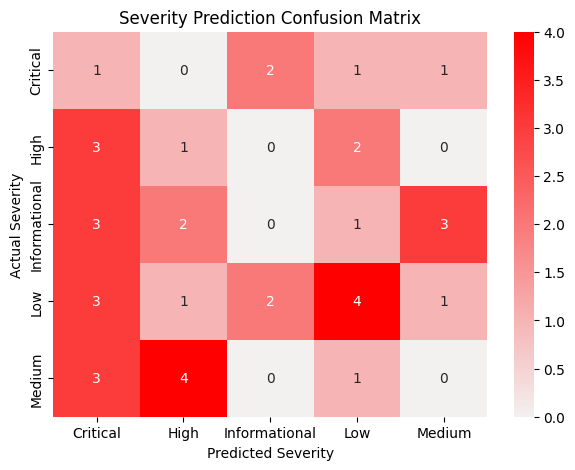

In [10]:
# Create confusion matrix heatmap to visualise errors and correct predictions
cm = confusion_matrix(y_test, y_pred)
light_red_cmap = sns.light_palette("red", as_cmap=True)
plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',                   # Decimal integer = 'd'
    xticklabels=severity_encoder.classes_,  # Columns = predicted classes
    yticklabels=severity_encoder.classes_, # Rows = actual classes
    cmap=light_red_cmap  # Add colour
)

plt.xlabel('Predicted Severity')
plt.ylabel('Actual Severity')
plt.title('Severity Prediction Confusion Matrix')
plt.show()